In [ ]:
#!pip install lime

In [23]:
import tensorflow as tf
import numpy as np
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [24]:
Image_Size = 128

In [25]:
model = tf.keras.models.load_model("model.h5")

In [26]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [27]:
def lime_predict(images):
    images = np.array(images)
    images = images / 255.0  
    return model.predict(images)

In [28]:
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

In [42]:
def explain_with_lime(img_path, model):
    # load image (NO augmentation here)
    img = load_img(img_path, target_size=(Image_Size, Image_Size))
    img = np.array(img)

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        img.astype('double'),
        lime_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000 
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    # prediction
    preds = model.predict(np.expand_dims(img/255.0, axis=0))
    pred_class = np.argmax(preds)
    confidence = np.max(preds)
    class_name = class_labels[pred_class]

    if class_name == 'notumor':
        result = "No Tumor"
    else:
        result = f"Tumor: {class_name}"

    # plot
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img.astype(np.uint8))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mark_boundaries(temp/255.0, mask))
    plt.title(f"LIME Explanation\n{result} ({confidence*100:.2f}%)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

  0%|                                                                                         | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


  1%|▊                                                                               | 10/1000 [00:01<01:42,  9.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step


  2%|█▌                                                                              | 20/1000 [00:02<01:38,  9.93it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step


 99%|██████████████████████████████████████████████████████████████████████████████▏| 990/1000 [01:42<00:01,  9.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:43<00:00,  9.66it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


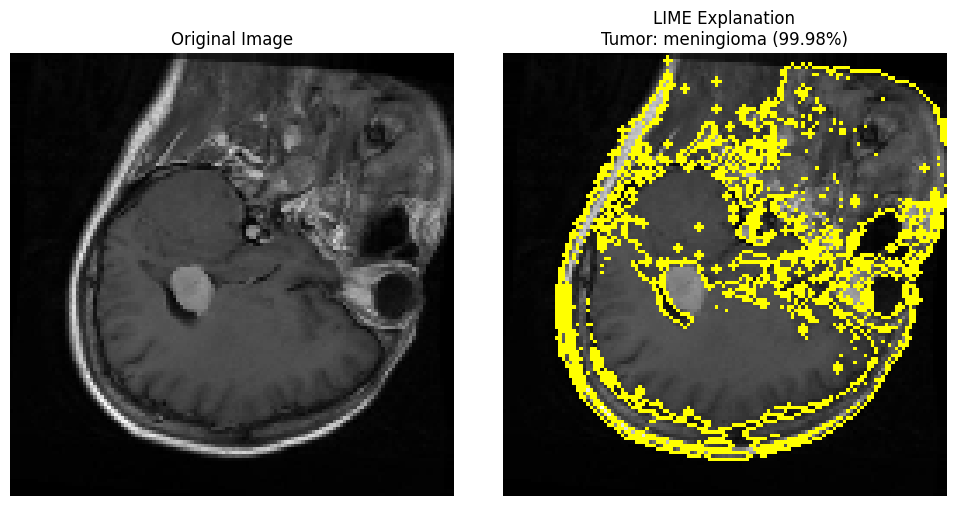

In [44]:
explain_with_lime('MRI/Testing/meningioma/Te-aug-me_13.jpg', model)